In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wasserstein_distance
import sys
import os

# Get absolute path to the folder
module_path = os.path.abspath('../data')

if module_path not in sys.path:
    sys.path.append(module_path)

from sampling import item_stereotypicality_sampling_dp as i_ster_sampling

In [2]:
def compute_ister_score(dataset_df, user_info_df):
    merged_df = pd.merge(dataset_df, user_info_df, left_on="user_id", right_on="user_id")
    item_attr_interactions_df = merged_df[["item_id", "attr"]]
    item_attr_dist = item_attr_interactions_df.groupby(["item_id", "attr"]).size()
    attr_dist = item_attr_interactions_df.groupby("attr").size()
    igi_score = item_attr_dist / attr_dist
    
    # compute i_ster score
    ister_scores = dict()
    for iid in dataset_df["item_id"].unique():
        if 0 not in igi_score.loc[iid] or 1 not in igi_score.loc[iid]:
            ister_scores[iid] = 0
        else:
            diff = igi_score.loc[iid][0] - igi_score.loc[iid][1]
            ister_scores[iid] = diff / max(igi_score.loc[iid][0], igi_score.loc[iid][1])
    
    return ister_scores

def measure_stereotypicality(user_stereotypicality, attr):
    if attr == 0:
        return user_stereotypicality
    else:
        return -user_stereotypicality
    
def _apply_dp(dataset_df, item_pool, privacy_budget):
    prob_keep = 1 / (np.exp(privacy_budget) + 1) + (np.exp(privacy_budget) - 1) / (np.exp(privacy_budget) + 1)

    new_dataset = []
    for user_id, dataset_user_df in dataset_df.groupby("user_id"):
        n_keep = np.ceil(len(dataset_user_df) * prob_keep).astype(int)
        keep_data = dataset_user_df.loc[np.random.choice(dataset_user_df.index, replace=False, size=n_keep)]
        new_dataset.extend(keep_data.to_records(index=False).tolist())

        neg_items = set(item_pool).difference(dataset_user_df["item_id"].unique())
        added_iids = np.random.choice(list(neg_items), replace=False, size=min(len(dataset_user_df) - n_keep, len(neg_items)))
        add_data = [(user_id, item_id, -1) for item_id in added_iids]
        new_dataset.extend(add_data)

    return pd.DataFrame.from_records(new_dataset, columns=["user_id", "item_id", "rating"])

In [3]:
dataset_df = pd.read_csv("ml1m/ml1m.dataset.rating", sep="\t", header=None, names=["user_id", "item_id", "rating"])

users_df = pd.read_csv("ml1m/ml1m.userlist", sep="\t")
users_df.columns = ["user_id", "attr"]

ister_scores = compute_ister_score(dataset_df, users_df)
dataset_df["i_ster"] = dataset_df["item_id"].map(ister_scores)

uster_scores = dataset_df.groupby("user_id")["i_ster"].mean()
users_df["u_ster"] = users_df["user_id"].map(uster_scores)

users_df["abs_u_ster"] = users_df.apply(lambda r: measure_stereotypicality(r["u_ster"], r["attr"]), axis=1)

# user analysis

In [23]:
df = dataset_df.merge(users_df)[["user_id", "item_id", "rating", "i_ster", "attr"]]

df["is_stereo"] = (((df["i_ster"] > 0) & (df["attr"] == 0)) | ((df["i_ster"] < 0) & (df["attr"] == 1))).astype(int)
df.groupby("user_id")["is_stereo"].mean().mean()

0.59725984598268

In [4]:
users_df.groupby("attr")["u_ster"].mean()

attr
0    0.082869
1   -0.076272
Name: u_ster, dtype: float64

attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

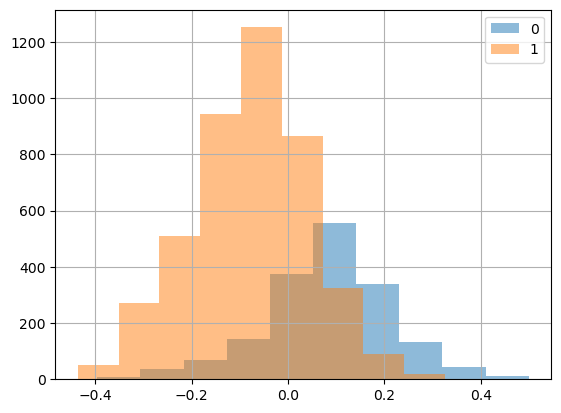

In [5]:
users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

In [6]:
users_df["attr"].value_counts() / len(users_df)

1    0.717053
0    0.282947
Name: attr, dtype: float64

In [7]:
df = dataset_df.merge(users_df, left_on="user_id", right_on="user_id")
df["is_stereo"] = (((df["attr"] == 0) & (df["i_ster"] > 0)) | ((df["attr"] == 1) & (df["i_ster"] < 0))).astype(int)
df.groupby("user_id")["is_stereo"].mean().mean()

0.59725984598268

In [8]:
users_df["abs_u_ster"].mean()

0.07813863539253435

In [9]:
u_ster0 = users_df[users_df["attr"] == 0]["u_ster"].values
u_ster1 = users_df[users_df["attr"] == 1]["u_ster"].values
wasserstein_distance(u_ster0, u_ster1)

0.1591409309287342

## select only stereotypical users

0.7817437097717964
0.7374740244747171
0.75
attr
0    0.132638
1   -0.128490
Name: u_ster, dtype: float64
1    0.705077
0    0.294923
Name: attr, dtype: float64
0.6376426186080526
0.6445912914482224
0.12971295983651446


attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

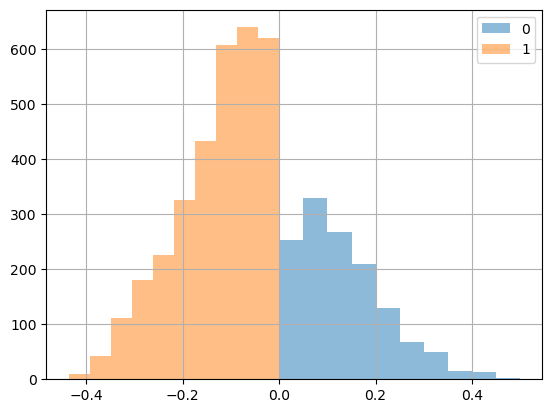

In [10]:
users0_df = users_df[(users_df["attr"] == 0) & (users_df["u_ster"] > 0)]
users1_df = users_df[(users_df["attr"] == 1) & (users_df["u_ster"] < 0)]

print(len(users0_df) / (users_df["attr"] == 0).sum())
print(len(users1_df) / (users_df["attr"] == 1).sum())

stereotypical_users_df = pd.concat([users0_df, users1_df])
print(len(stereotypical_users_df) / len(users_df))

print(stereotypical_users_df.groupby("attr")["u_ster"].mean())

print(stereotypical_users_df["attr"].value_counts() / len(stereotypical_users_df))

df = dataset_df.merge(stereotypical_users_df, left_on="user_id", right_on="user_id")
print((df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).mean())
print((df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).mean())

print(stereotypical_users_df["abs_u_ster"].mean())
stereotypical_users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

In [11]:
print(len(stereotypical_users_df) / len(users_df))
stereotypical_users_df["abs_u_ster"].mean()

0.75


0.12971295983651446

In [12]:
users0_df = users_df[(users_df["attr"] == 0) & (users_df["u_ster"] < 0)]
users1_df = users_df[(users_df["attr"] == 1) & (users_df["u_ster"] > 0)]

antistereotypical_users_df = pd.concat([users0_df, users1_df])
print(len(antistereotypical_users_df) / len(users_df))
print(antistereotypical_users_df.groupby("attr")["u_ster"].mean())
print(antistereotypical_users_df["abs_u_ster"].mean())

0.25
attr
0   -0.095393
1    0.070414
Name: u_ster, dtype: float64
-0.07658433793940594


In [13]:
stereotypical_users_df = users_df[users_df["abs_u_ster"] > 0.1]

In [14]:
stereotypical_users = stereotypical_users_df["user_id"].values
stereotypical_df = df[df["user_id"].isin(stereotypical_users)]

user_map = {old: new for new, old in enumerate(stereotypical_df["user_id"].unique())}
item_map = {old: new for new, old in enumerate(stereotypical_df["item_id"].unique())}

stereotypical_df["user_id"] = stereotypical_df["user_id"].map(user_map)
stereotypical_df["item_id"] = stereotypical_df["item_id"].map(item_map)
stereotypical_df.rename(columns={"user_id": "user_id:token", "item_id": "item_id:token", "rating": "rating:token", "attr": "attr:token"}, inplace=True)

stereotypical_df[["user_id:token", "item_id:token", "rating:token"]].to_csv("ml1m.dataset.rating", sep="\t", index=False, header=False)
stereotypical_df.drop_duplicates(subset=["user_id:token", "attr:token"]).to_csv("ml1m.userlist", sep="\t", index=False)

C:\Users\pmuellner\AppData\Local\Temp\ipykernel_35300\1996163161.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stereotypical_df["user_id"] = stereotypical_df["user_id"].map(user_map)
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_35300\1996163161.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stereotypical_df["item_id"] = stereotypical_df["item_id"].map(item_map)
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_35300\1996163161.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy 

# item analysis

In [15]:
items0 = dict()
items1 = dict()
for iid, score in ister_scores.items():
    if score > 0:
        items0[iid] = score
    elif score < 0:
        items1[iid] = score

print(len(items0) / len(ister_scores), len(items1) / len(ister_scores))
print(np.mean(list(items0.values())), np.mean(list(items1.values())))

0.46735024284943333 0.4624932541824069
0.36780553228746565 -0.3582444678672929


# other

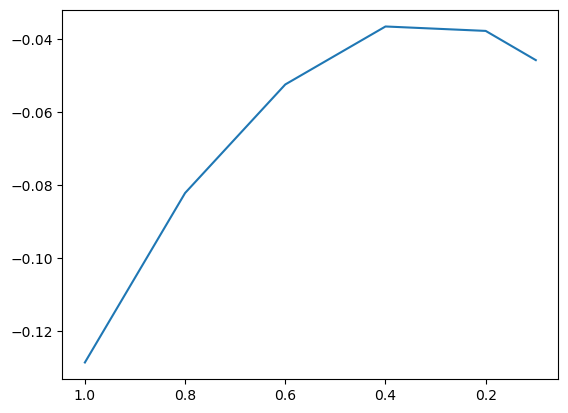

In [16]:
def get_uster_per_beta(df, beta):
    u_sters = []
    for user_id, group_df in df.groupby("user_id"):
        attr = group_df["attr"].values[0]
        if attr == 0:
            sorted_df = group_df.sort_values(by="i_ster", ascending=True)
        else:
            sorted_df = group_df.sort_values(by="i_ster", ascending=False)
            
        if attr ==  0:
            continue

        n_keep = int(len(group_df) * beta)
        keep_df = sorted_df[:n_keep][["user_id", "item_id", "rating"]]
        dp_df = group_df.loc[list(set(group_df.index).difference(keep_df.index))]

        item_pool = set(df["item_id"].unique()).difference(group_df["item_id"].values)
        dp_df = _apply_dp(dp_df[["user_id", "item_id", "rating"]], item_pool, privacy_budget=0.1)

        total_df = pd.concat([keep_df, dp_df])
        u_ster = total_df["item_id"].map(ister_scores).mean()
        #u_sters.append(measure_stereotypicality(u_ster, attr))
        
        u_sters.append(u_ster)
        
    return np.mean(u_sters)

betas = [1, 0.8, 0.6, 0.4, 0.2, 0.1]
usters = [get_uster_per_beta(df, b) for b in betas]

plt.plot(betas, usters)
plt.gca().invert_xaxis()

In [350]:
df.drop_duplicates(subset=["user_id"])["abs_u_ster"].mean()

0.12971295983651446

In [17]:
usters

[0.12971295983651446,
 0.10478584702516257,
 0.08330022561852932,
 0.06683002195713687,
 0.05384073089770143,
 0.04422644318778525,
 0.03827234952213977,
 0.037232839637395244,
 0.04038898241017996,
 0.04782531342069477]